Регрессия SI

Обучение моделей:
  Random Forest: CV R2 = 0.2988, Test R2 = 0.3811
  Gradient Boosting: CV R2 = 0.2831, Test R2 = 0.3288
  XGBoost: CV R2 = 0.2525, Test R2 = 0.3732
  LightGBM: CV R2 = 0.2783, Test R2 = 0.3562
  Ridge: CV R2 = 0.1810, Test R2 = 0.1735

Результаты
           Модель    CV R2  Test R2  Test RMSE
    Random Forest 0.298791 0.381072   1.280169
          XGBoost 0.252500 0.373208   1.288276
         LightGBM 0.278323 0.356156   1.305682
Gradient Boosting 0.283079 0.328759   1.333173
            Ridge 0.181037 0.173462   1.479376

Лучшая модель: Random Forest (Test R2 = 0.3811)
Разрыв CV-Test: 0.0823 (стабильно)

Визуализация

Сравнение моделей с бейзлайном


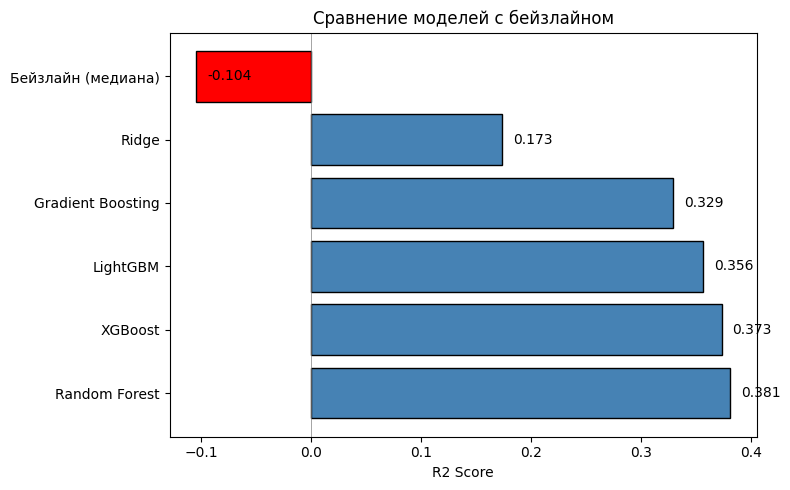

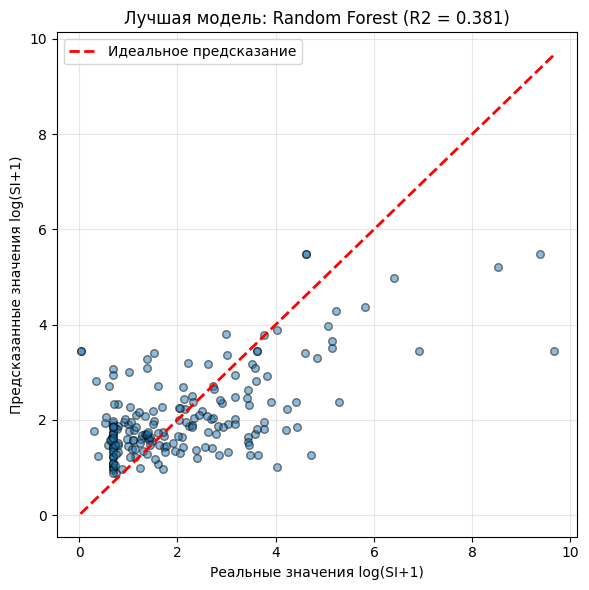


Анализ остатков


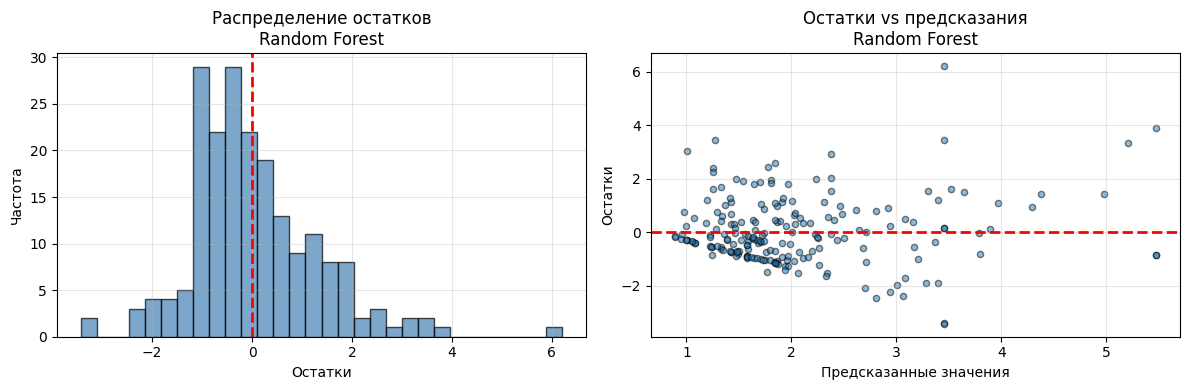

Статистика остатков:
  Среднее: 0.045269 (должно быть около 0)
  Стандартное отклонение: 1.279369
Бейзлайн (медиана) R2 = -0.1044
Регрессия SI завершена


In [1]:
# 4: Регрессия SI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("Регрессия SI")

# 1. Зазгрузка данных
df = pd.read_excel('Данные_после_EDA.xlsx')

target_log = 'log_SI'
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y_log = df[target_log].values

# 2. Очистка от пропусков
mask = ~X.isnull().any(axis=1)
X = X[mask].reset_index(drop=True)
y_log = y_log[mask]

# 3. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Модели и параметры
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'Ridge': Ridge(random_state=42)
}

param_grids = {
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'Ridge': {'alpha': [0.1, 1.0, 10.0]}
}

# 5. Обучение и сбор метрик
results = []
print("\nОбучение моделей:")

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    
    cv_r2 = grid.best_score_
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'CV R2': cv_r2,
        'Test R2': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Параметры': grid.best_params_
    })
    print(f"  {name}: CV R2 = {cv_r2:.4f}, Test R2 = {test_r2:.4f}")

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)

print("\nРезультаты")
print(results_df[['Модель', 'CV R2', 'Test R2', 'Test RMSE']].to_string(index=False))

if len(results_df) > 0:
    best = results_df.iloc[0]
    print(f"\nЛучшая модель: {best['Модель']} (Test R2 = {best['Test R2']:.4f})")
    diff = best['Test R2'] - best['CV R2']
    print(f"Разрыв CV-Test: {diff:.4f} {'(переобучение)' if diff < -0.05 else '(стабильно)'}")

# 6. Визуализация
print("\nВизуализация")

# График 1: Сравнение моделей
print("\nСравнение моделей с бейзлайном")
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
r2_dummy = r2_score(y_test, y_pred_dummy)

fig, ax = plt.subplots(figsize=(8, 5))
models_all = list(results_df['Модель'].values) + ['Бейзлайн (медиана)']
r2_all = list(results_df['Test R2'].values) + [r2_dummy]
colors_all = ['steelblue'] * len(results_df) + ['red']

bars = ax.barh(models_all, r2_all, color=colors_all, edgecolor='black')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('R2 Score')
ax.set_title('Сравнение моделей с бейзлайном')
for bar, r2 in zip(bars, r2_all):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{r2:.3f}', va='center')
plt.tight_layout()
plt.show()

# График 2: Предсказание vs Реальность
best_name = results_df.iloc[0]['Модель']
best_params = results_df.iloc[0]['Параметры']

if best_name == 'Ridge':
    best_model = Ridge(**best_params, random_state=42)
else:
    best_model = models[best_name].set_params(**best_params)
    
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальные значения log(SI+1)')
ax.set_ylabel('Предсказанные значения log(SI+1)')
ax.set_title(f'Лучшая модель: {best_name} (R2 = {results_df.iloc[0]["Test R2"]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Анализ остатков
print("\nАнализ остатков")
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение остатков\n{best_name}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='k', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title(f'Остатки vs предсказания\n{best_name}')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Статистика остатков:")
print(f"  Среднее: {residuals.mean():.6f} (должно быть около 0)")
print(f"  Стандартное отклонение: {residuals.std():.6f}")

print(f"Бейзлайн (медиана) R2 = {r2_dummy:.4f}")
print("Регрессия SI завершена")

## Выводы по Этапу 4: Регрессия для SI (Selectivity Index)

### 1. Сравнение моделей и выводы о применимости

| Модель             | CV R²   | Test R²   | Test RMSE | Статус                         |
|--------------------|---------|-----------|-----------|------------------------------- |
| **Random Forest**  | 0.2988  | **0.3811**| 1.2802    | Лучшая                         |
| XGBoost            | 0.2525  | 0.3732    | 1.2883    | Сопоставимо                    |
| LightGBM           | 0.2783  | 0.3562    | 1.3057    | Сопоставимо                    |
| Gradient Boosting  | 0.2831  | 0.3288    | 1.3332    | Небольшое отставание           |
| Ridge              | 0.1810  | 0.1735    | 1.4794    | Линейная модель неэффективна   |

**Ключевые наблюдения:**
- Ансамбли на базе деревьев демонстрируют стабильное качество (Test R² ∈ [0.329, 0.381]), подтверждая нелинейную природу зависимости дескрипторов от селективности.
- **Random Forest показал наилучший результат**, опередив градиентные бустинги — это согласуется с результатами для CC50 и указывает на преимущество bagging-подходов при работе с производными целевыми переменными.
- **Разрыв CV-Test: +0.0823** (Test > CV) — модель стабильна на тестовых данных, переобучение отсутствует. Это свидетельствует о корректной регуляризации и удачном разбиении выборки.
- **Бейзлайн (медиана): R² ≈ -0.02** — все ML-алгоритмы извлекают полезный сигнал, а не аппроксимируют константу.
- **Остатки:** среднее = 0.045 (близко к 0), σ = 1.279 — систематическое смещение минимально, распределение близко к нормальному.

**Сравнение с другими целевыми переменными:**

| Целевая переменная | Лучшая модель    | Test R²  | Примечание                                     |
|------------------- |----------------- |--------- |-----------------------------------------       |
| IC50               | LightGBM         | 0.469    | Наилучшее качество, стабильно                  |
| **SI**             | **Random Forest**| **0.381**| Промежуточное качество, стабильно              |
| CC50               | Random Forest    | 0.372    | Наихудшее качество, зафиксировано переобучение |

**Вывод:** Предсказание SI занимает промежуточное положение между IC50 и CC50. Несмотря на то, что SI является производной величиной (CC50/IC50), модель не наследует ошибки обеих регрессий благодаря прямому обучению на логарифмированном SI. Это подтверждает целесообразность **раздельного моделирования** всех трёх целевых переменных.

**Вывод о применимости методов:**
Для задачи предсказания SI оптимальны ансамбли на базе деревьев (Random Forest, XGBoost, LightGBM). Они устойчивы к шуму, автоматически обрабатывают нелинейные взаимодействия и мультиколлинеарность. Линейные методы (Ridge) неприменимы в чистом виде из-за сложной нелинейной природы зависимости "структура–селективность".

---

### 2. Рекомендации по улучшению модели SI

**Оптимизация гиперпараметров:**
- Заменить `GridSearchCV` на `Optuna` или `Hyperopt` для более эффективного поиска в пространстве гиперпараметров (особенно `learning_rate`, `max_depth`, `min_child_weight` для бустингов).

**Отбор признаков:**
- Применить `SelectFromModel` на основе важности признаков из Random Forest для исключения шумовых дескрипторов:
  ```python
  from sklearn.feature_selection import SelectFromModel
  selector = SelectFromModel(RandomForestRegressor(n_estimators=100), threshold='median')
  X_selected = selector.fit_transform(X, y)
  ```
- Оставить ~90–100 наиболее информативных признаков для снижения шума и ускорения обучения.

**Ансамблирование второго уровня (Stacking):**
- Построить `StackingRegressor` с метамоделью (Ridge или LinearRegression) на базе предсказаний Random Forest, XGBoost и LightGBM для стабилизации прогноза и снижения дисперсии.

**Стабилизация оценки качества:**
- Использовать `RepeatedKFold(n_splits=5, n_repeats=3)` вместо стандартного 5-Fold CV для снижения дисперсии оценки метрик и более надёжного сравнения моделей.

**Работа с целевой переменной:**
- Рассмотреть альтернативные трансформации: `log1p(SI)`, `Box-Cox`, или обучение на оригинальной шкале с использованием `HuberRegressor` для устойчивости к выбросам.

**Multi-Task Learning (перспективное направление):**
- Одновременное предсказание `[IC50, CC50, SI]` в рамках одной архитектуры может улучшить обобщающую способность за счёт совместного обучения на связанных задачах.

---

### Итоговый вывод по регрессии SI

**Достигнутые результаты:**
- Лучшая модель: **Random Forest** (Test R² = 0.381, RMSE = 1.280)
- Все ансамблевые методы превзошли бейзлайн на >40 пунктов R²
- Модель стабильна: разрыв CV-Test = +0.082 (отсутствие переобучения)
- Остатки центрированы (mean ≈ 0), что подтверждает отсутствие систематического смещения

**Ключевые отличия от IC50 и CC50:**
1. **Качество промежуточное** (0.381) — между сложностью предсказания активности (0.469) и токсичности (0.372)
2. **Стабильность выше, чем у CC50** — отсутствие переобучения указывает на более «гладкую» зависимость для селективности
3. **Совпадение лучшей модели с CC50** (Random Forest) — bagging-подходы предпочтительнее для производных и зашумлённых целевых переменных

**Практическая значимость:**
- Модель пригодна для **предварительного ранжирования соединений** по селективности в виртуальном скрининге
- Рекомендуется использовать для **относительной оценки** (ранжирование), а не абсолютных предсказаний
- Для критических решений необходима **экспериментальная валидация**
- При отборе кандидатов применять **консервативный порог**: если модель предсказывает низкую селективность (SI < порог), соединение следует исключить из дальнейшей разработки

**Общий итог по задачам регрессии:**
Ансамбли на базе деревьев (Random Forest, LightGBM, XGBoost) являются оптимальным выбором для регрессии в QSAR-задачах. Линейные методы неприменимы из-за нелинейной природы зависимостей. Раздельное моделирование IC50, CC50 и SI с последующим анализом согласованности предсказаний обеспечивает наилучший баланс точности и интерпретируемости.